# Dataset Normalization
- Normalize each dataset to the range 0–1 based on metric direction

In [6]:
import os
import pandas as pd, numpy as np


ROOT_DIR = os.path.dirname(os.getcwd()) 

df = pd.read_csv(os.path.join(ROOT_DIR, "results", "admet_results_cv.csv"))  

def larger_is_better(metric):
    metric = metric.upper()
    return not any(key in metric for key in ["MAE"])

def normalise(group):
    vals = group["mean"] # Mean values of the metric
    if larger_is_better(group.name[1]): # group.name = (data_name, metric)
        norm = (vals - vals.min()) / (vals.max() - vals.min())
    else:
        norm = (vals.max() - vals) / (vals.max() - vals.min())
    return norm

# add a new column with the normalised values
df["norm"] = (
    df.groupby(["data_name", "metric"], group_keys=False)
      .apply(normalise)
)

print(df.head())


   task_group data_name   metric   model   mean    std      norm
0  Absorption     Caco2      MAE  D-MPNN  0.316  0.011  0.888889
1  Absorption       HIA  ROC_AUC  D-MPNN  0.980  0.019  0.972603
2  Absorption       Pgp  ROC_AUC  D-MPNN  0.935  0.019  0.571429
3  Absorption     Bioav  ROC_AUC  D-MPNN  0.695  0.067  0.500000
4  Absorption      Lipo      MAE  D-MPNN  0.387  0.013  0.976331


# Heatmap

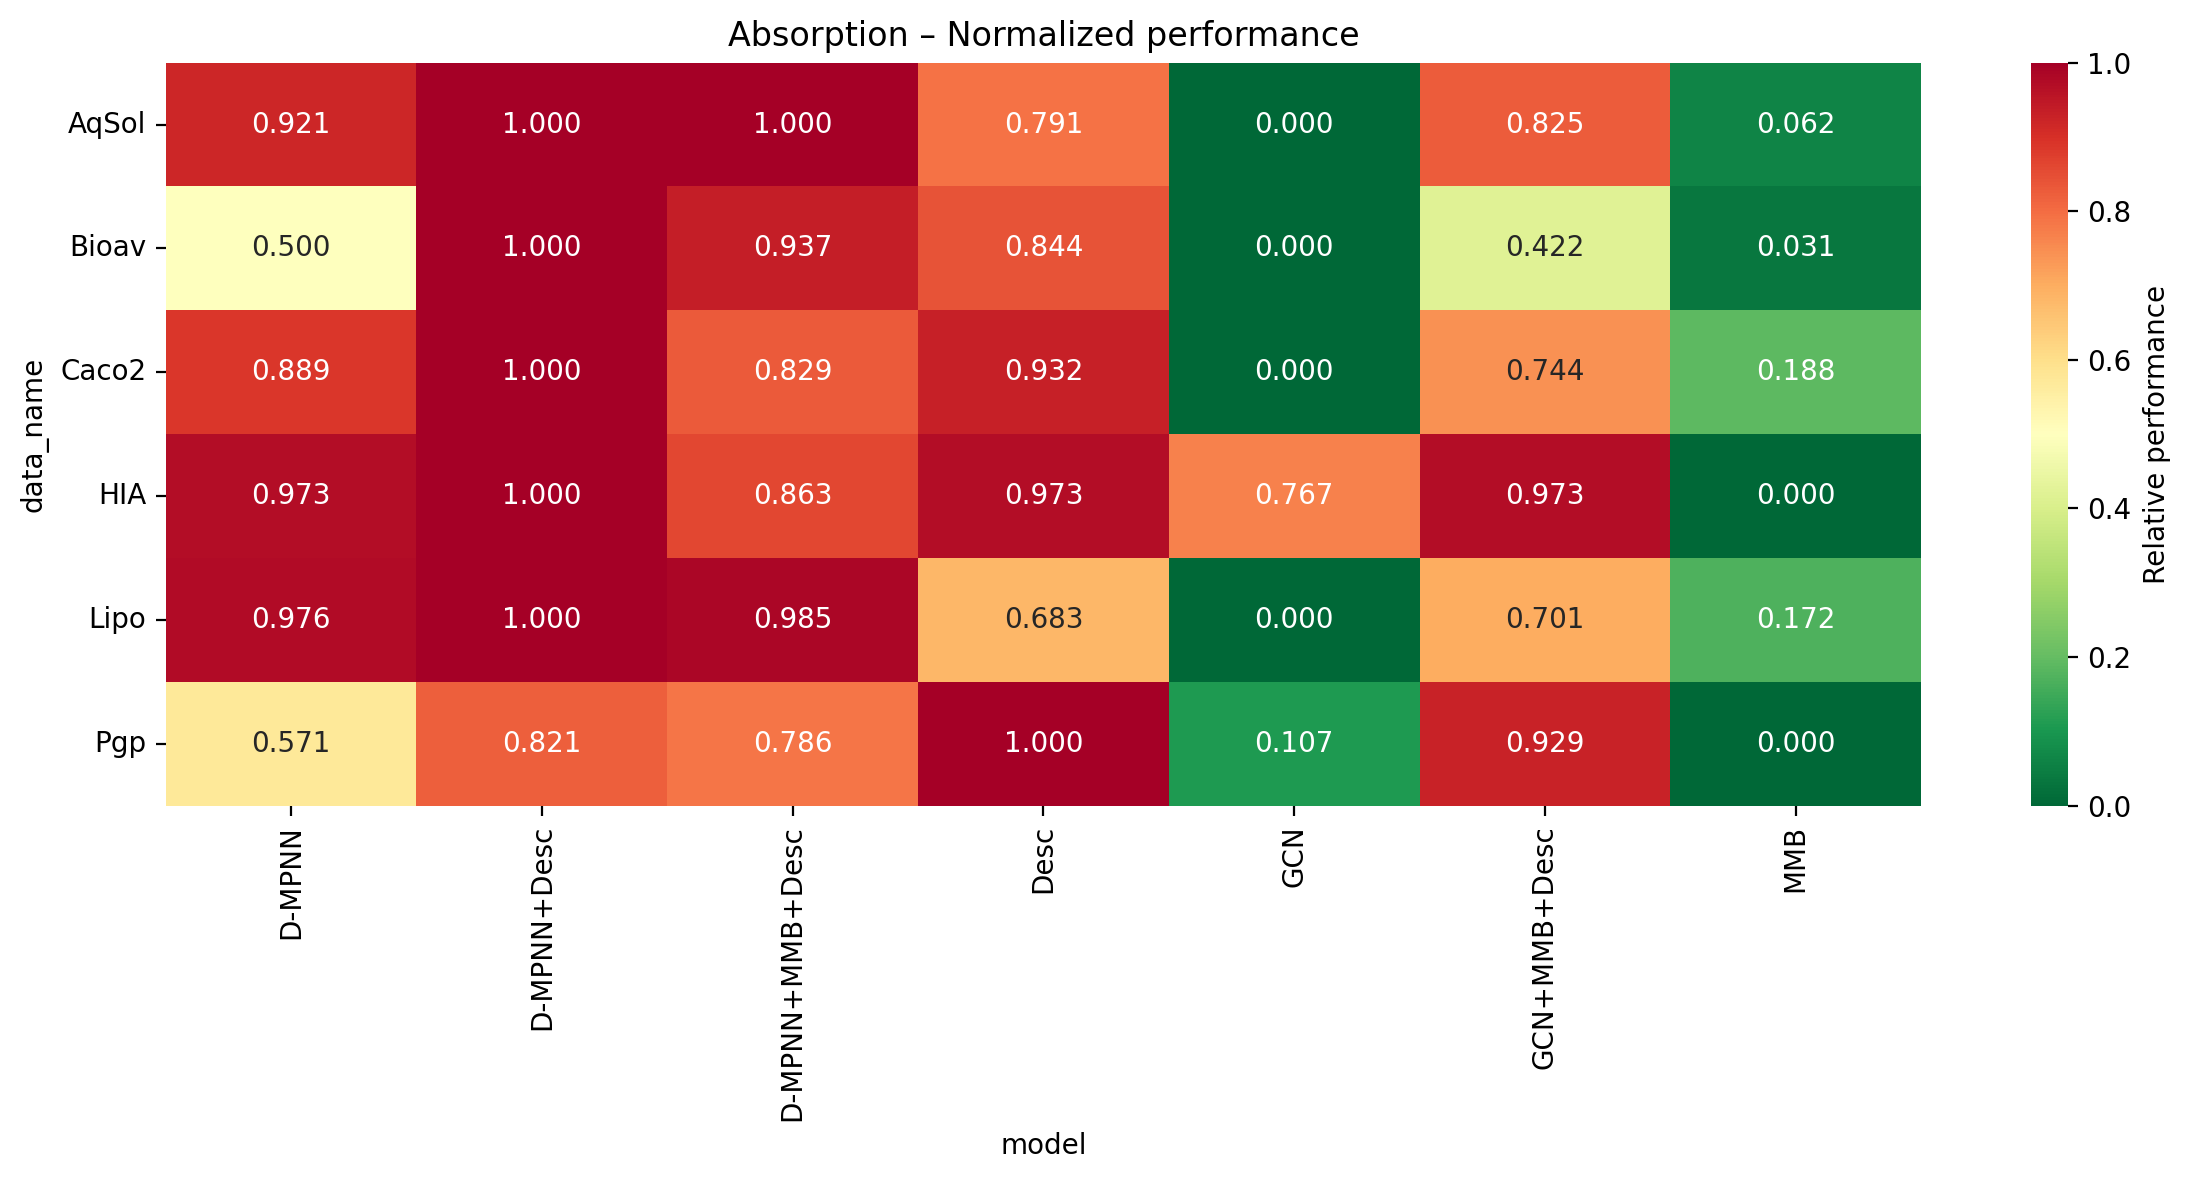

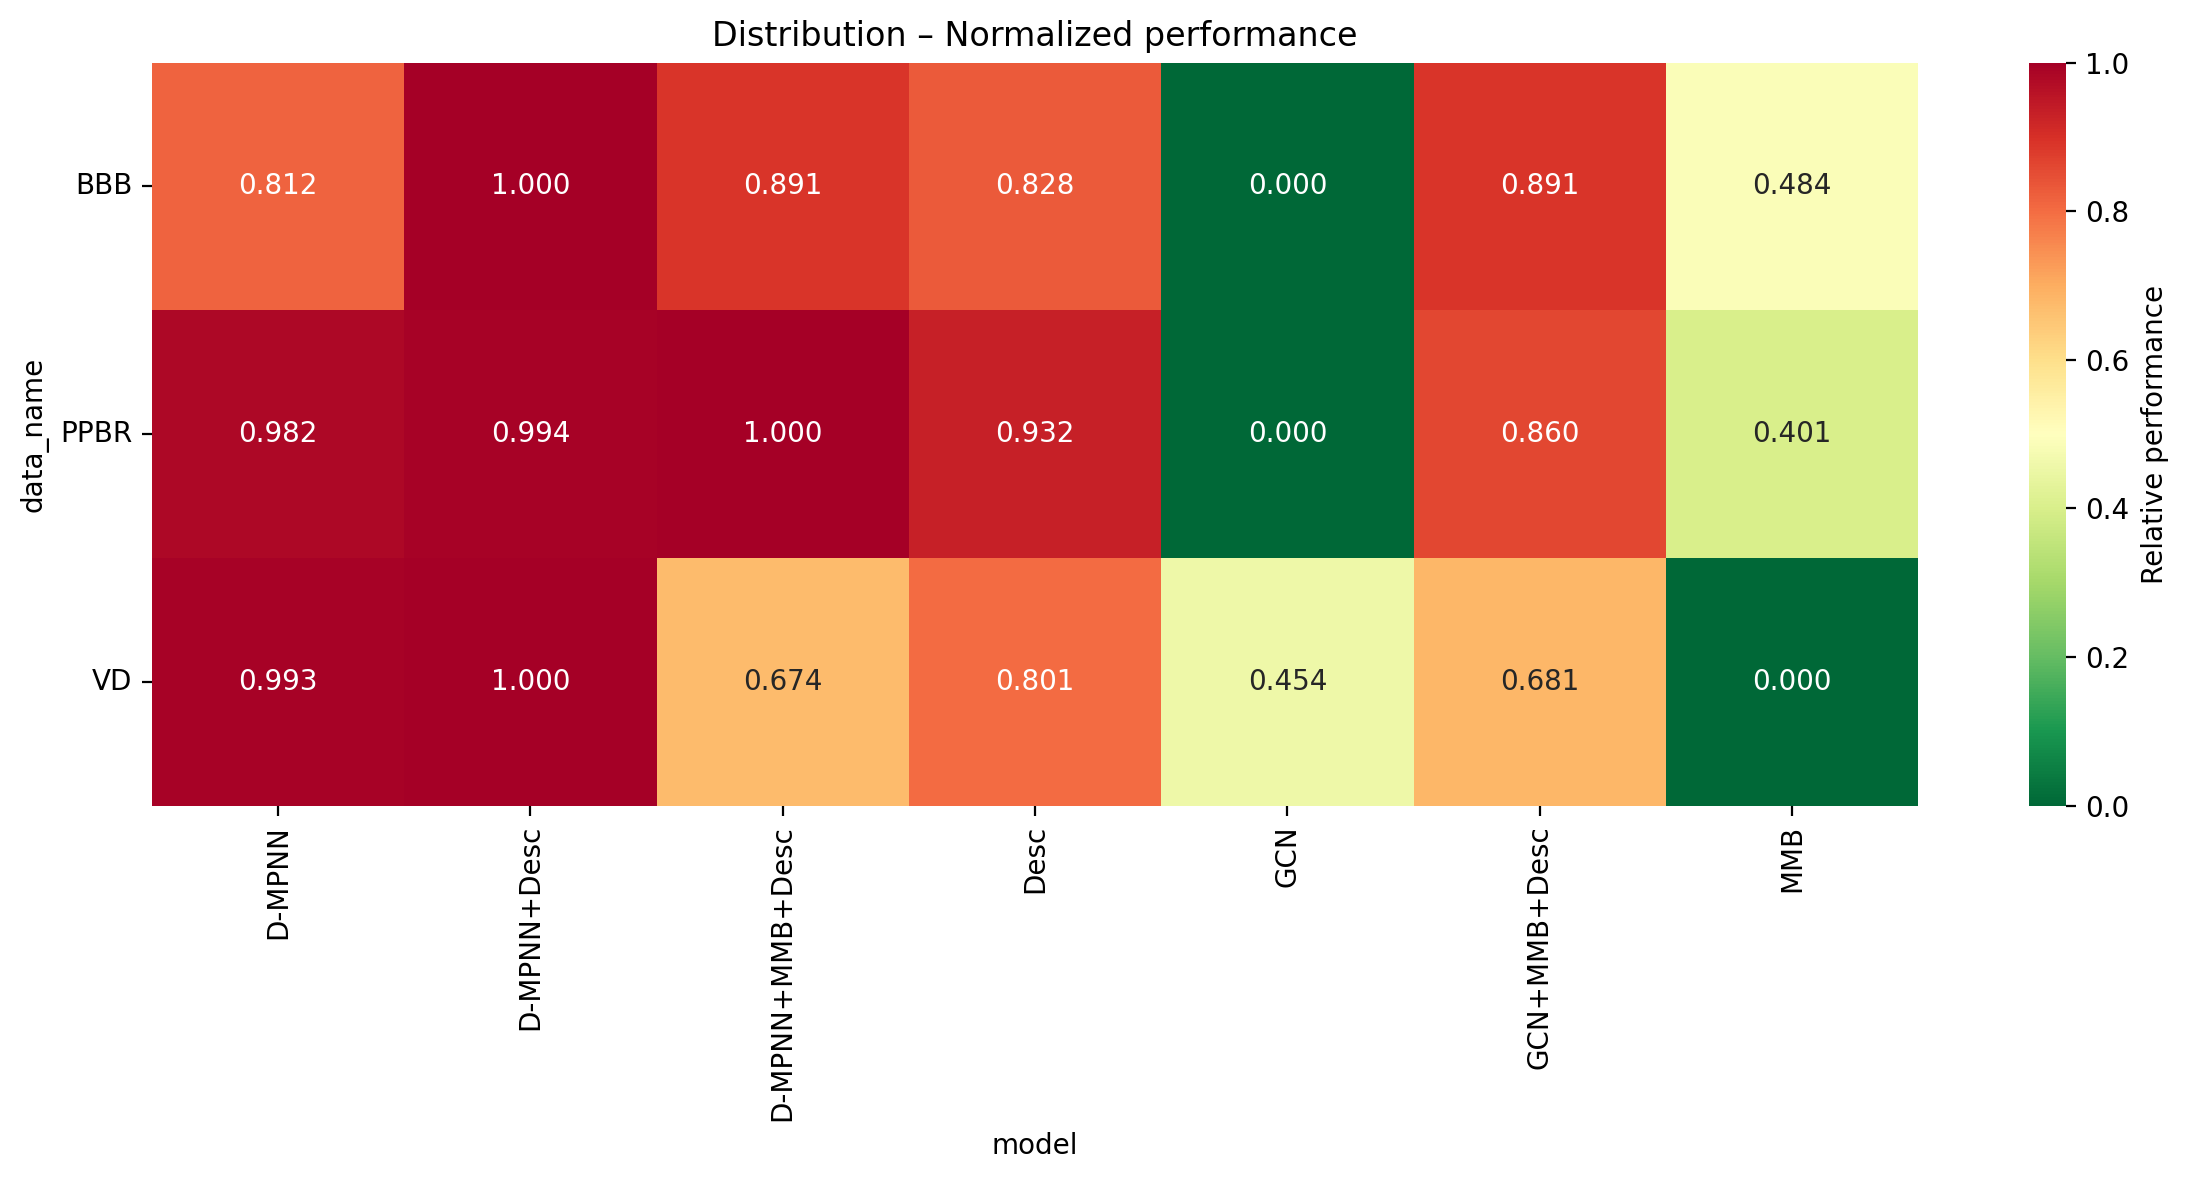

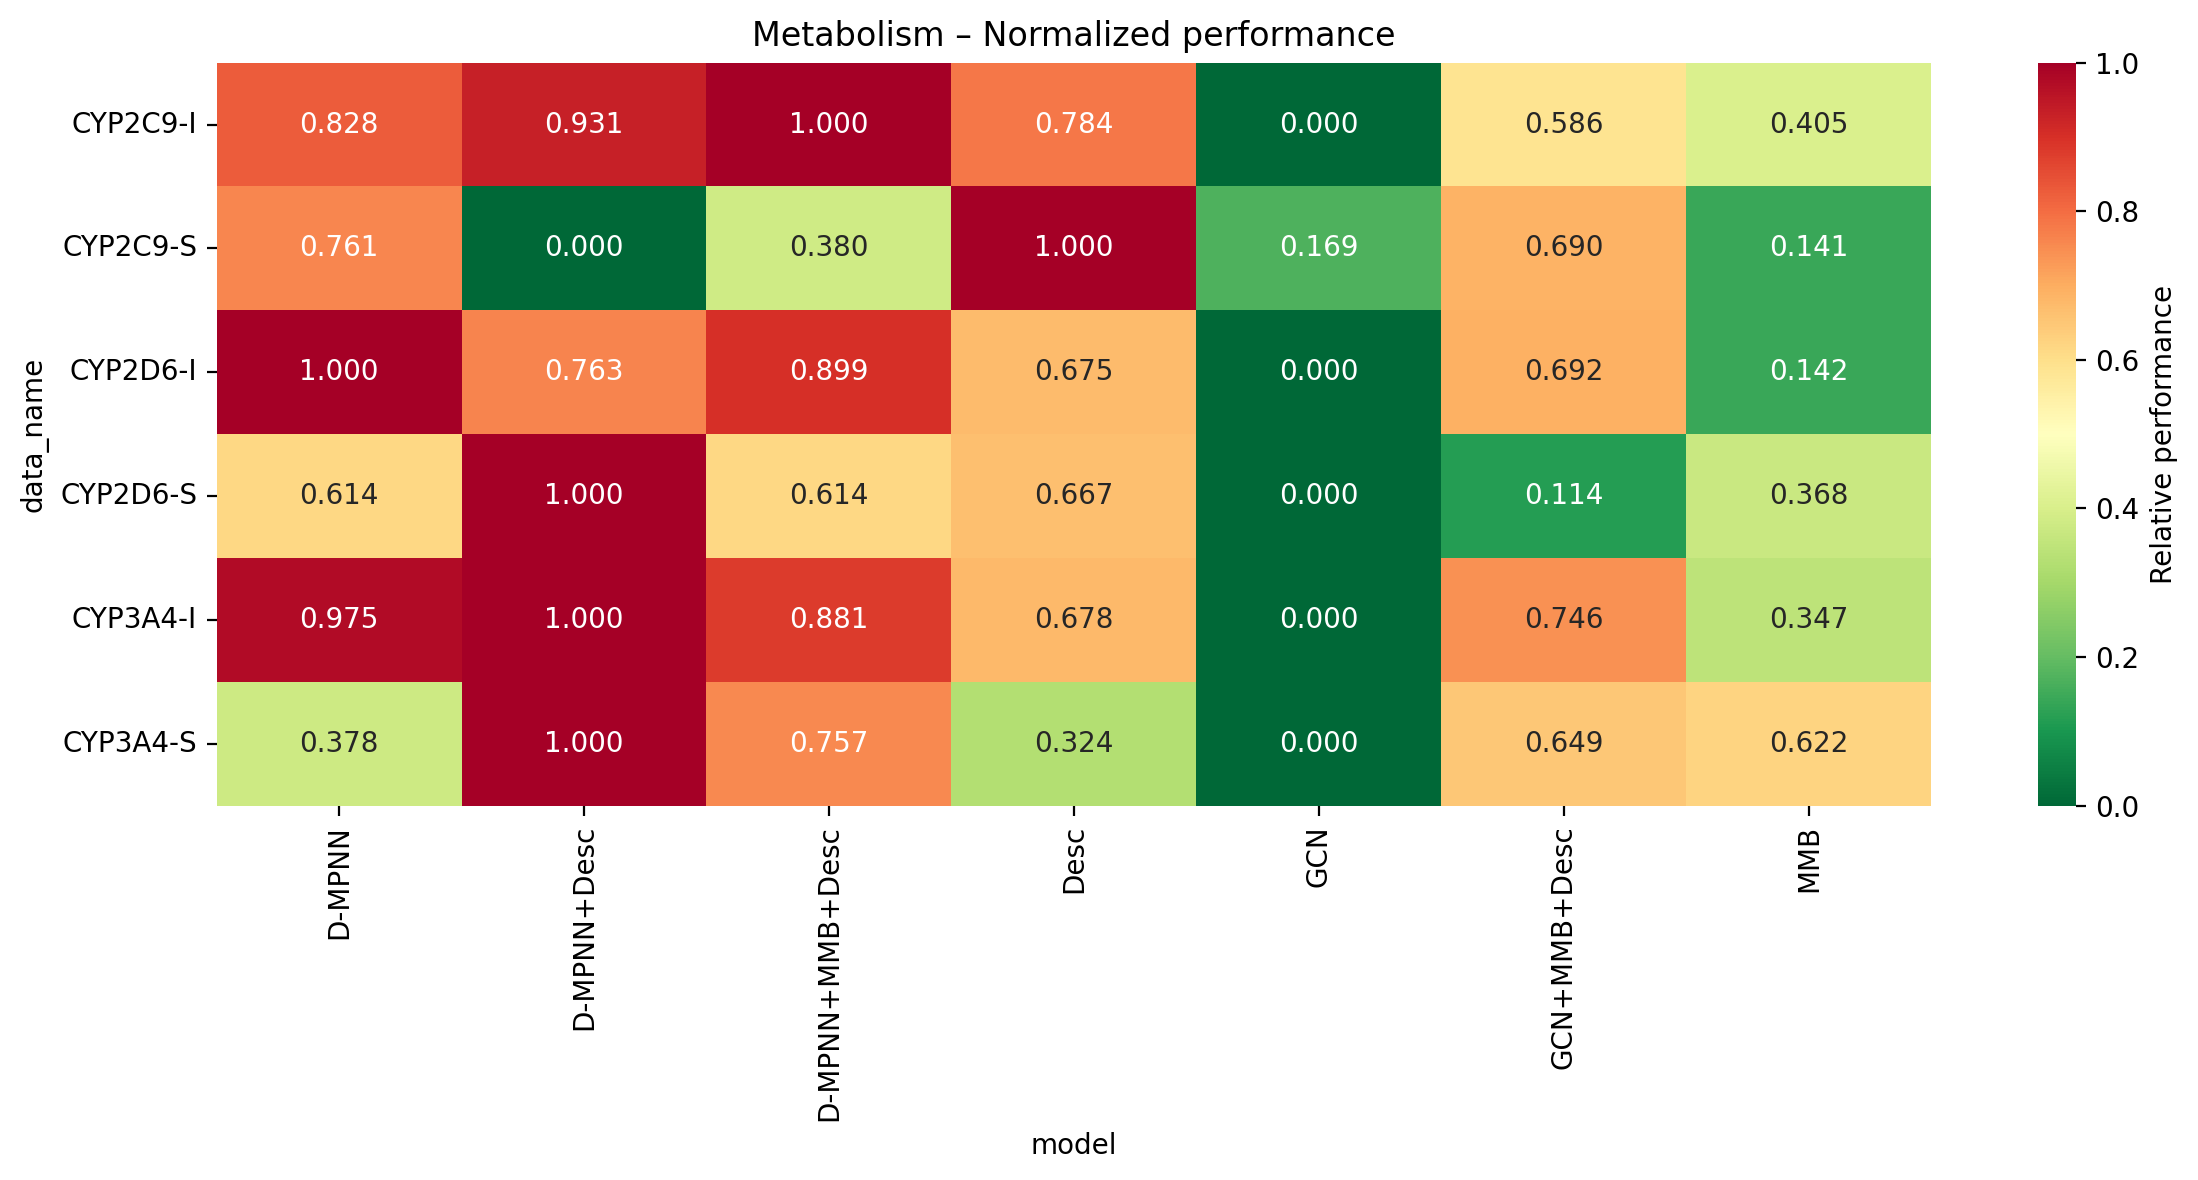

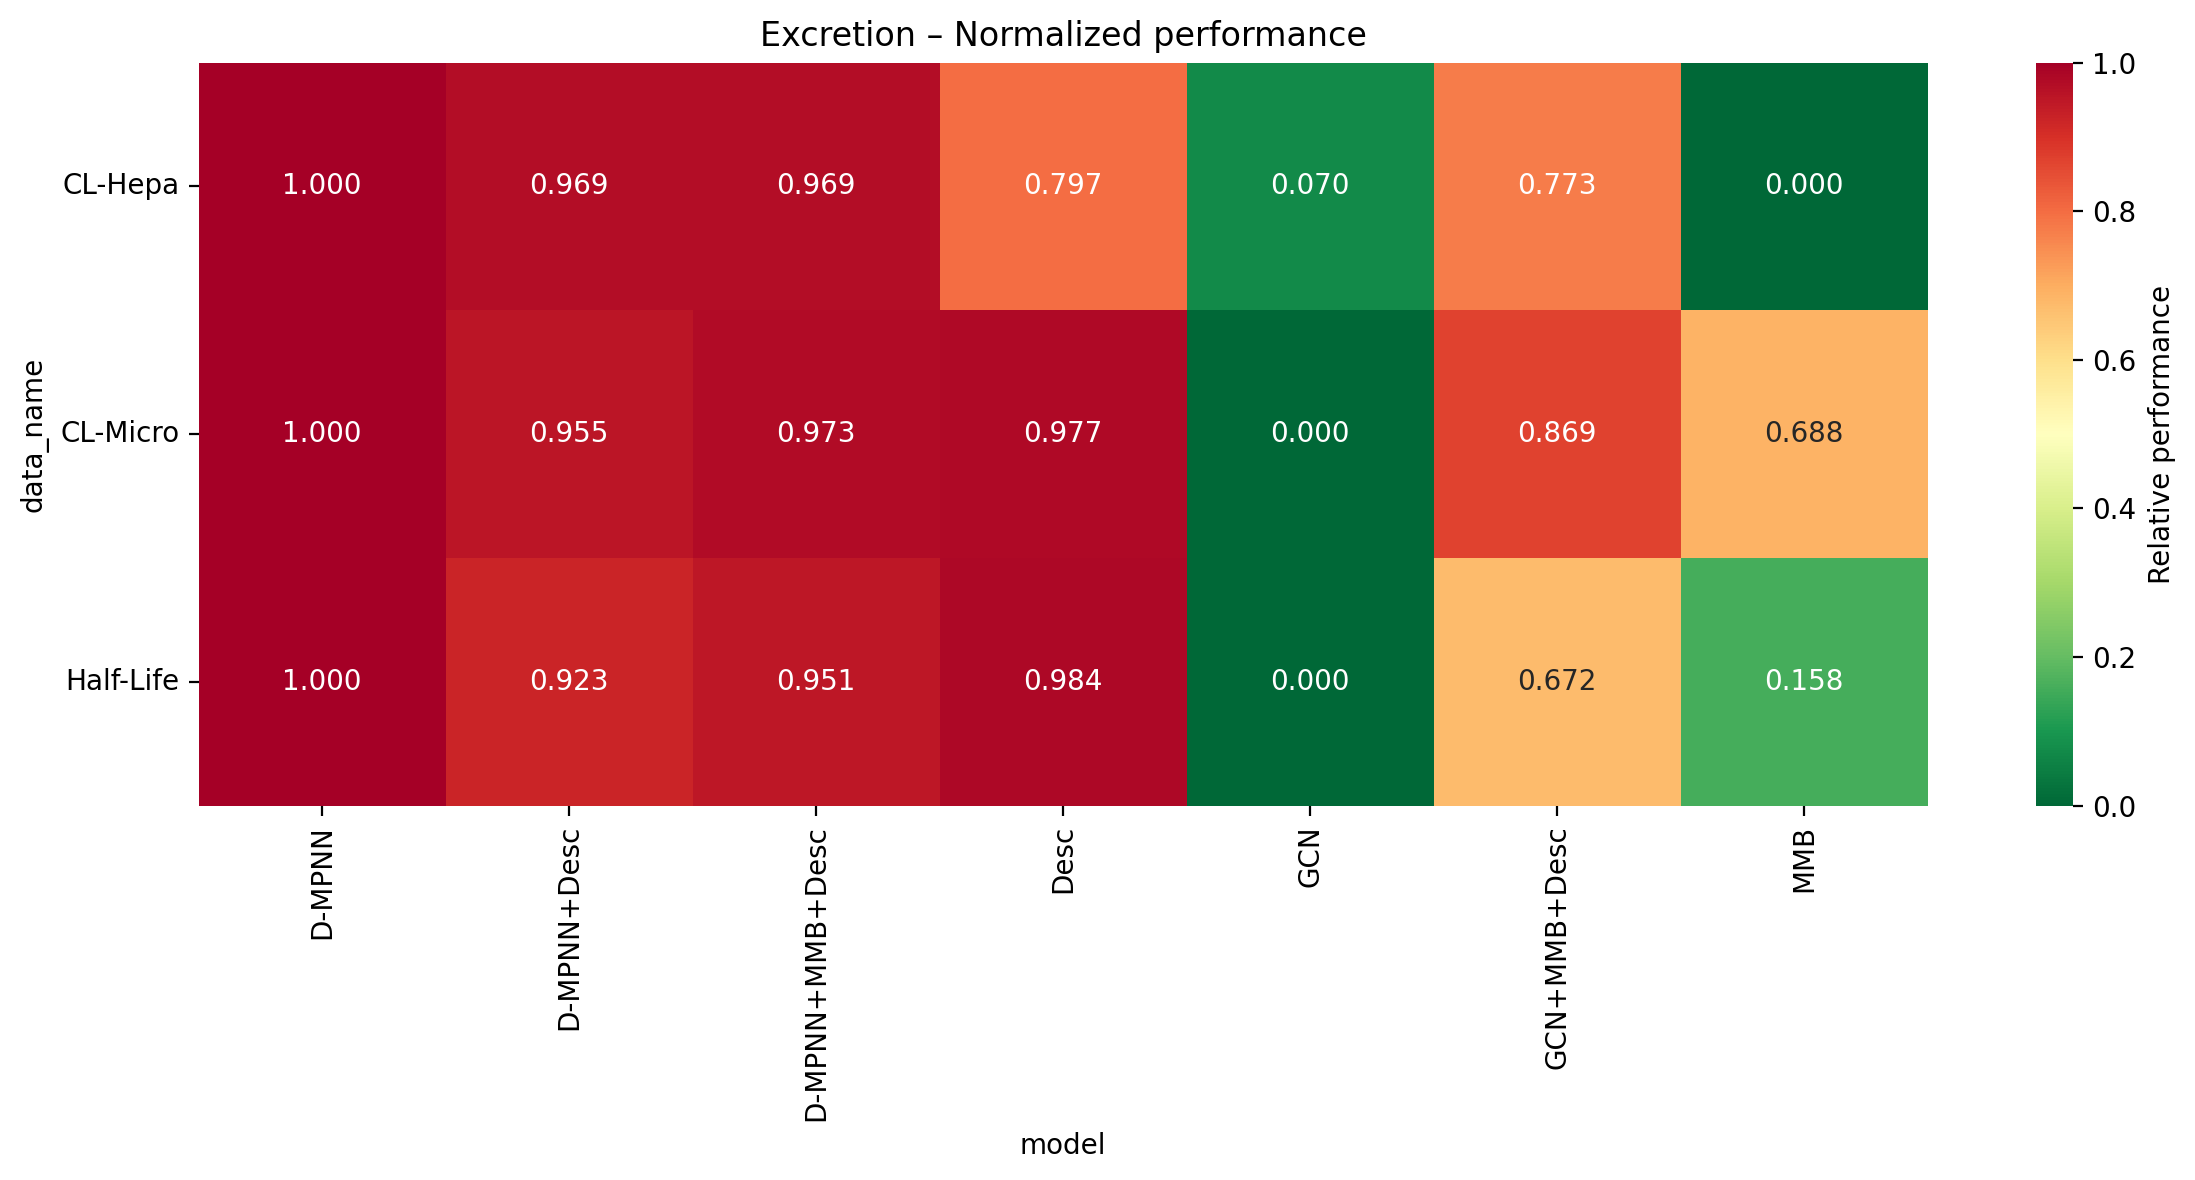

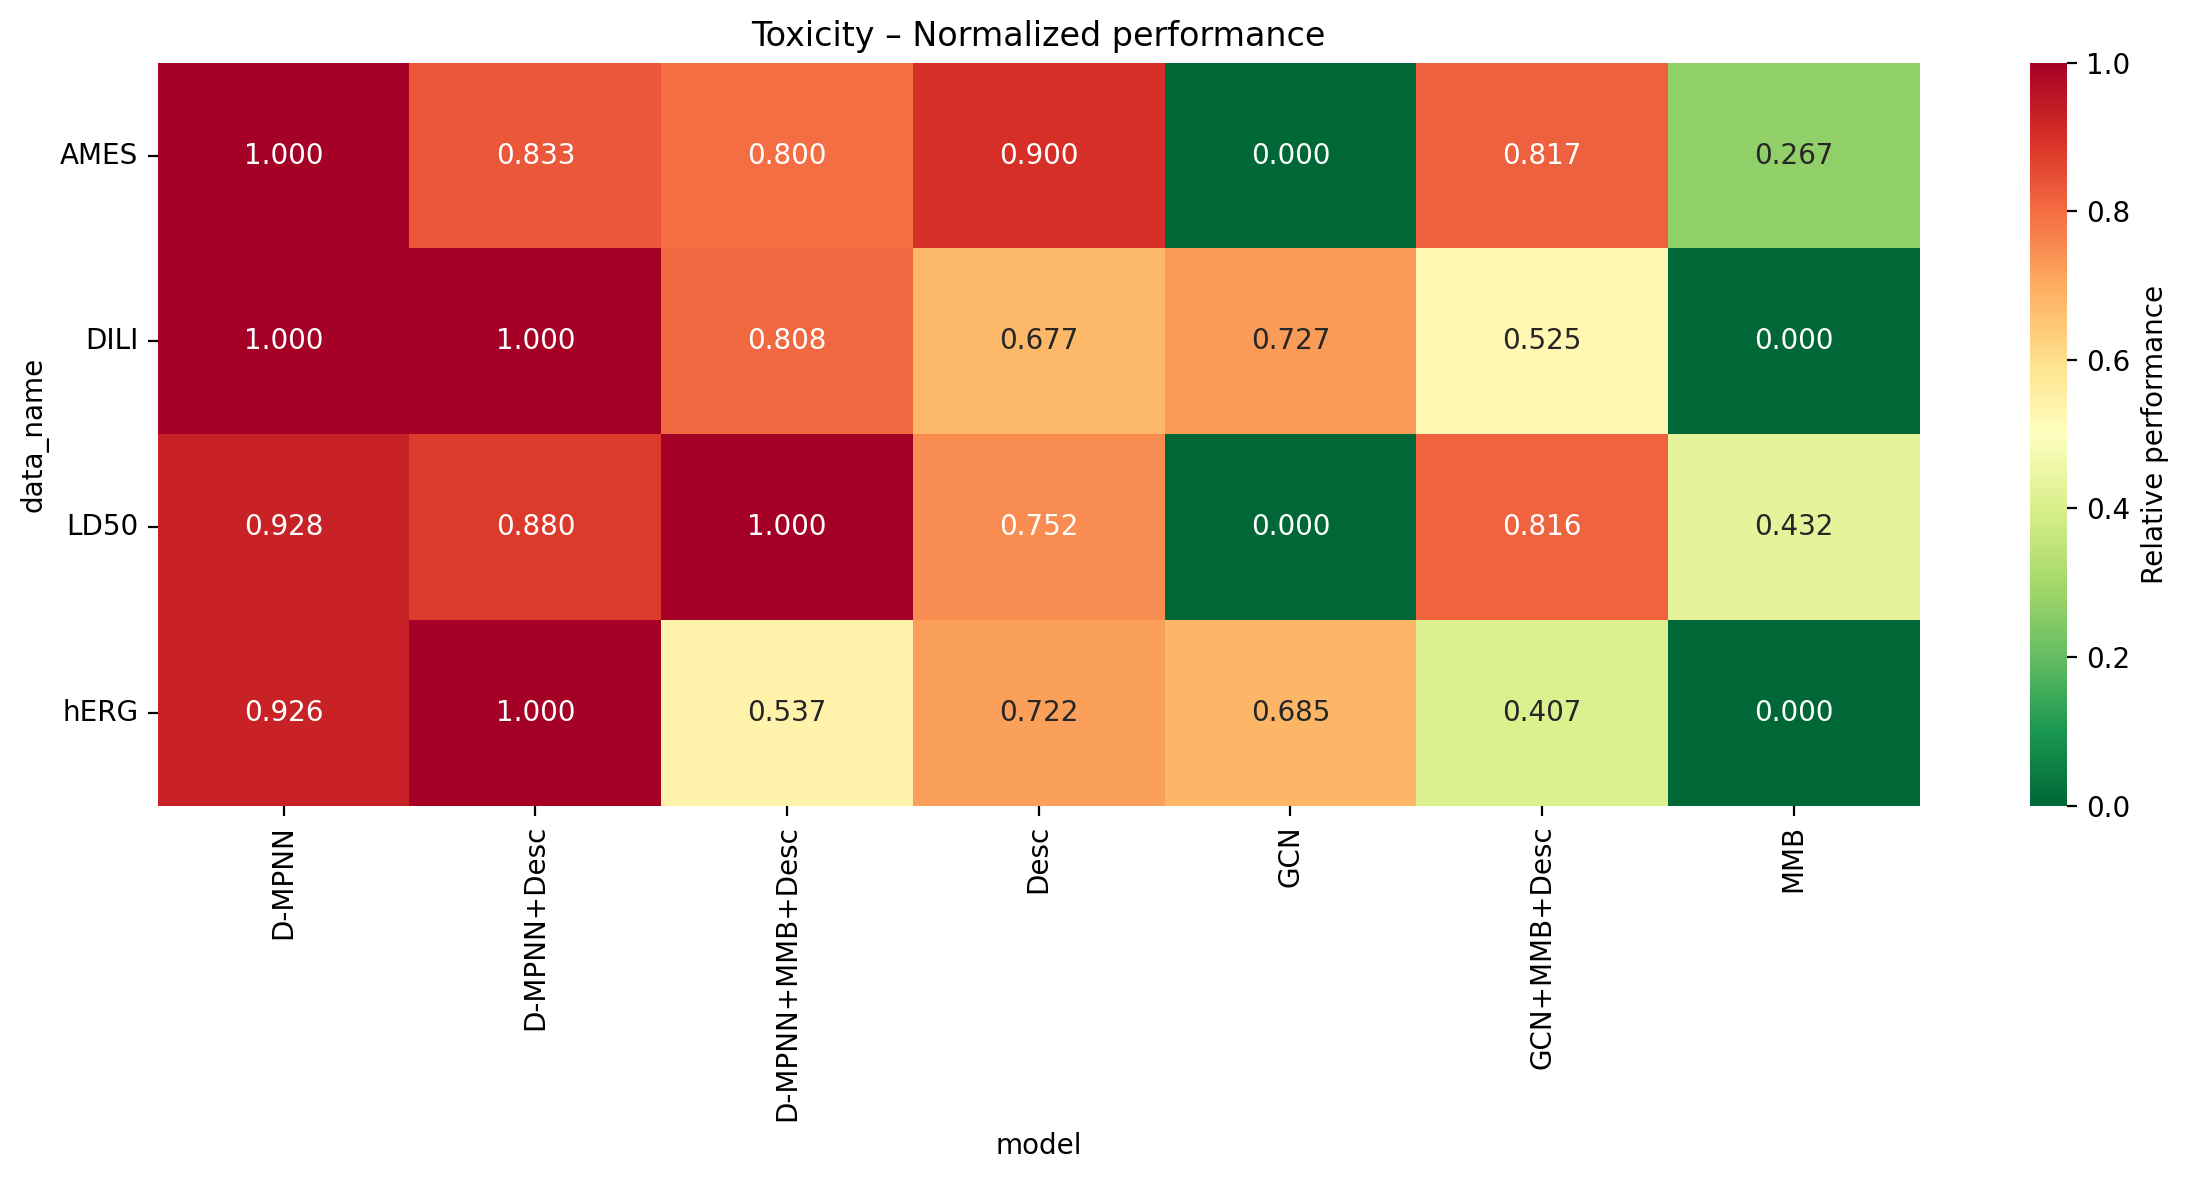

In [7]:
import seaborn as sns, matplotlib.pyplot as plt  
    
df["dataset_metric"] = df["data_name"] + "_" + df["metric"]

task_groups = df["task_group"].unique()
for tg in task_groups:
    heat_df = (
        df.query("task_group == @tg")
          # .pivot(index="dataset_metric", columns="model", values="norm")
          .pivot(index="data_name", columns="model", values="norm")
    )
    
    plt.figure(figsize=(12, 6), dpi=200)
    sns.heatmap(heat_df, cmap="RdYlGn_r", annot=True, fmt=".3f",
                vmin=0, vmax=1, cbar_kws={"label": "Relative performance"})
    plt.title(f"{tg} – Normalized performance")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


# Radar chart

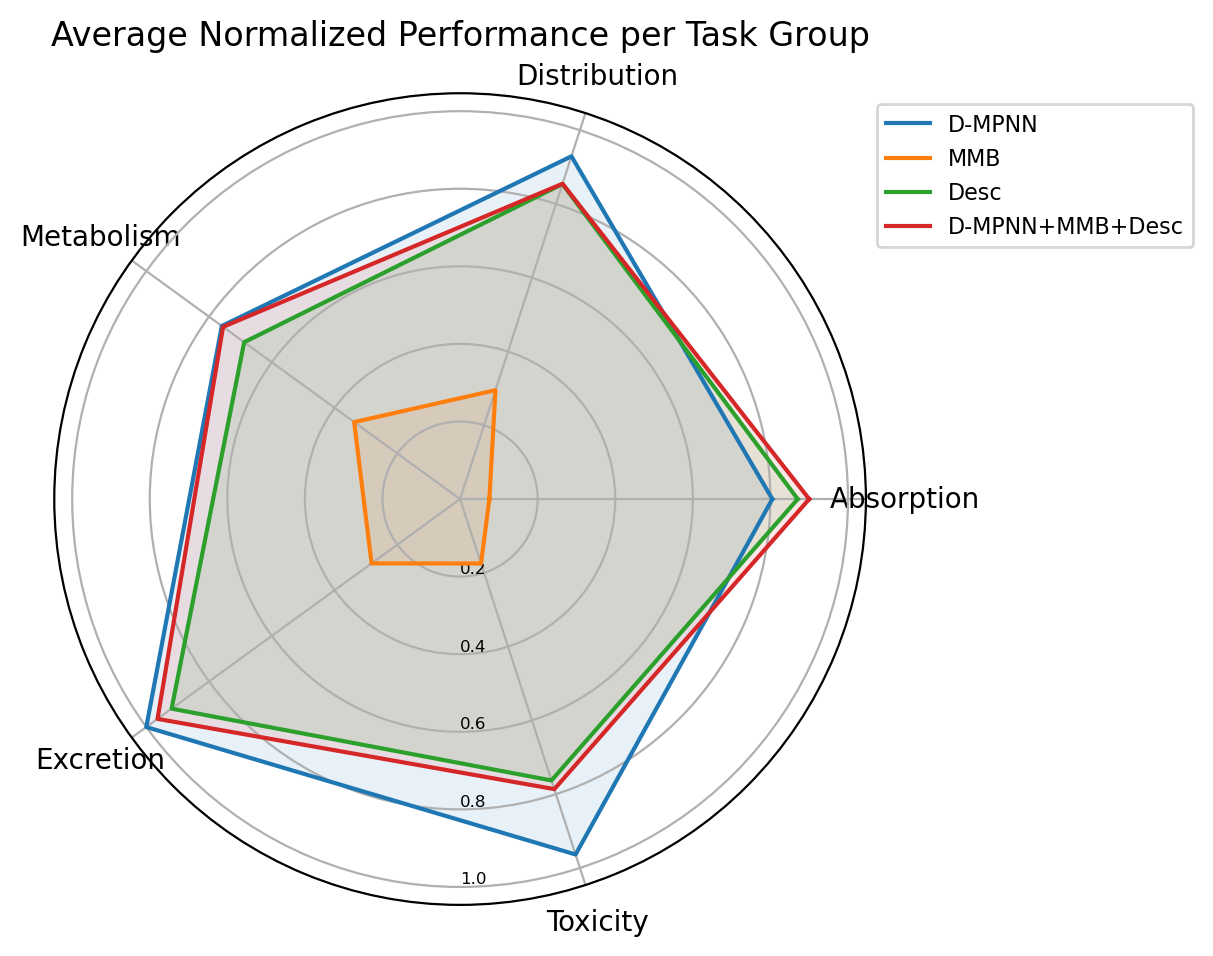

In [ ]:
# --- Compute per‑task‑group average for selected models ------------------
models_to_plot = ["D-MPNN", "MMB", "Desc", "D-MPNN+MMB+Desc"]
task_groups = ["Absorption", "Distribution", "Metabolism", "Excretion", "Toxicity"]

exclude_tasks = ["AqSol_MAE", "CYP2D6-I_PR_AUC", "CYP3A4-I_PR_AUC"]  # not needed
filtered_df = df[~df["data_name"].isin(exclude_tasks)]

radar_df = (filtered_df[filtered_df["model"].isin(models_to_plot)]
              .groupby(["task_group", "model"])["norm"]
              .mean()
              .unstack())

# make sure the rows are ordered
radar_df = radar_df.reindex(task_groups)

# --- Radar plot ----------------------------------------------------------
labels = radar_df.index.tolist()
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]  # close the loop

plt.figure(figsize=(6, 6), dpi=200)
ax = plt.subplot(111, polar=True)

for model in models_to_plot:
    values = radar_df[model].tolist()
    values += values[:1]  # close loop
    ax.plot(angles, values, label=model)
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
# ax.set_yticklabels([])
ax.set_rlabel_position(270) # Adjust radial labels
ax.tick_params(axis='y', labelsize=6) # Adjust radial label size
plt.title("Average Normalized Performance per Task Group")
plt.legend(loc='upper left', fontsize=8, bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()